# Introduction
Here is the project competition link: https://www.kaggle.com/competitions/gan-getting-started

Summary From Kaggle: A GAN consists of at least two neural networks: a generator model and a discriminator model. The generator is a neural network that creates the images. For our competition, you should generate images in the style of Monet. This generator is trained using a discriminator.

The two models will work against each other, with the generator trying to trick the discriminator, and the discriminator trying to accurately classify the real vs. generated images.

We want to build a GAN that generates 7,000 to 10,000 Monet-style images.

Submissions are evaluated on MiFID (Memorization-informed Fréchet Inception Distance)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
current_directory = os.getcwd()
print("Current working directory:", current_directory)
os.chdir("/kaggle/input/gan-getting-started")
print("Current working directory:", current_directory)
os.listdir(current_directory)

Current working directory: /kaggle/working
,Current working directory: /kaggle/working


['__notebook__.ipynb']

### Setup and EDA

In [2]:
# SETUP AND IMPORTS
import tensorflow as tf
import matplotlib.pyplot as plt
import zipfile
#!pip install tensorflow-addons -q

# EXPLORATORY DATA ANALYSIS (EDA)

# Define paths 
MONET_JPG_DIR = './monet_jpg/'
PHOTO_JPG_DIR = './photo_jpg/'

# Count the number of images
num_monet_images = len(os.listdir(MONET_JPG_DIR))
num_photo_images = len(os.listdir(PHOTO_JPG_DIR))

print(f"Number of Monet paintings: {num_monet_images}")
print(f"Number of photos: {num_photo_images}")

2025-10-12 18:41:46.625898: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
,WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
,E0000 00:00:1760294506.810457      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
,E0000 00:00:1760294506.870474      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Number of Monet paintings: 300
,Number of photos: 7038


### Display sample images to have an idea what we're working with


,Sample Monet Paintings:


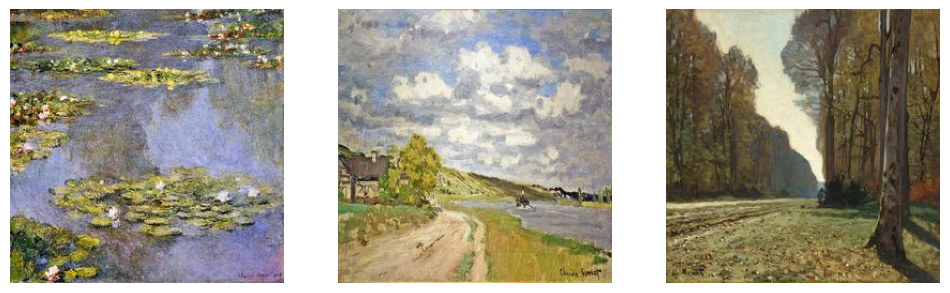

Sample Photos:


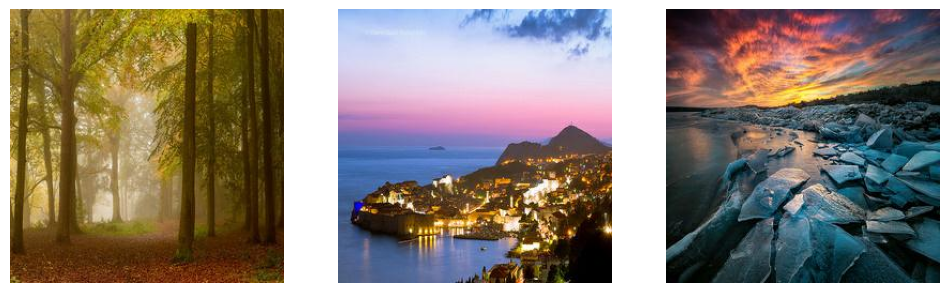

In [3]:
def display_samples(directory, num_samples=3):
    plt.figure(figsize=(12, 4))
    image_files = os.listdir(directory)[:num_samples]
    for i, file_name in enumerate(image_files):
        img = tf.keras.utils.load_img(os.path.join(directory, file_name))
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

print("\nSample Monet Paintings:")
display_samples(MONET_JPG_DIR)
print("Sample Photos:")
display_samples(PHOTO_JPG_DIR)


### Plot some histograms to see the color distributions of the images


,Color Distribution Analysis:


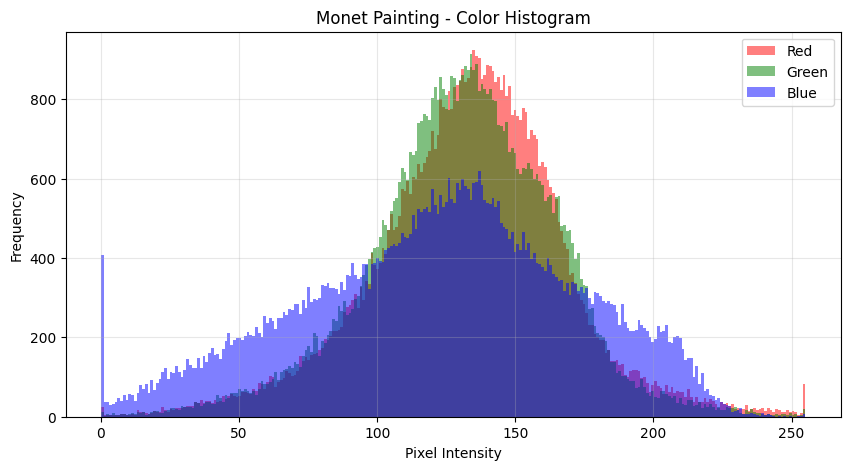

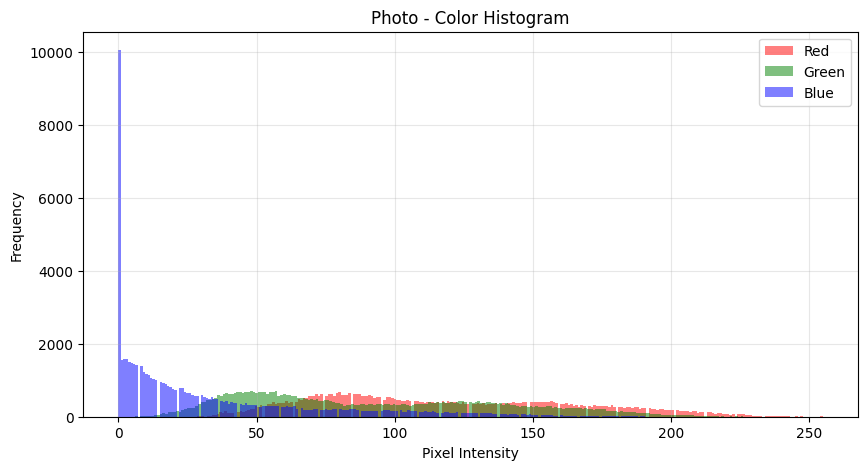

In [4]:
#plot color channel histograms
def plot_histograms(directory, title):
    # Load one image to analyze
    image_file = os.listdir(directory)[0]
    img = plt.imread(os.path.join(directory, image_file))
    
    plt.figure(figsize=(10, 5))
    plt.title(title)
    
    # Plot histograms for each channel
    plt.hist(img[:, :, 0].ravel(), bins=256, color='red', alpha=0.5, label='Red')
    plt.hist(img[:, :, 1].ravel(), bins=256, color='green', alpha=0.5, label='Green')
    plt.hist(img[:, :, 2].ravel(), bins=256, color='blue', alpha=0.5, label='Blue')
    
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\nColor Distribution Analysis:")
plot_histograms(MONET_JPG_DIR, "Monet Painting - Color Histogram")
plot_histograms(PHOTO_JPG_DIR, "Photo - Color Histogram")


We can see from the Color Distribution Analysis that blue is the most frequent color used out of red, blue, and green in the provided photos. Red and green seem to be the highest number of colors in the Monet paintings.

# Model Architecture

### DATA PIPELINE

In [5]:
# DATA PIPELINE (TFRecord Version)
import tensorflow as tf
import numpy as np
import random, glob

# Constants
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 256
BATCH = 4
SEED = 1337
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

#  Define TFRecord paths using glob to find all .tfrec files 

MONET_TFREC_PATHS = glob.glob('./monet_tfrec/*.tfrec')
PHOTO_TFREC_PATHS = glob.glob('./photo_tfrec/*.tfrec')
print(f"Found Monet TFRecords: {len(MONET_TFREC_PATHS)} | Photo TFRecords: {len(PHOTO_TFREC_PATHS)}")

# Preprocessing functions
def decode_center_crop_resize(img_bytes):
    img = tf.io.decode_jpeg(img_bytes, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    side = tf.minimum(h, w)
    img = tf.image.crop_to_bounding_box(img, (h - side)//2, (w - side)//2, side, side)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bicubic")
    return img

def preprocess_train(img):
    img = tf.image.resize(img, [286, 286], method="bicubic")
    img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])
    img = tf.image.random_flip_left_right(img)
    img = (img * 2.0) - 1.0
    return img

def preprocess_infer(img):
    img = (img * 2.0) - 1.0
    return img

# function to parse the serialized data from TFRecords
def _parse_function(example_proto):
    feature_description = {'image': tf.io.FixedLenFeature([], tf.string)}
    features = tf.io.parse_single_example(example_proto, feature_description)
    return features['image']


def make_ds(tfrec_paths, training=True):
    if not tfrec_paths:
        return None

    # Create dataset from TFRecord files for high performance
    ds = tf.data.TFRecordDataset(tfrec_paths, num_parallel_reads=AUTOTUNE)

    # Extract the raw image bytes from the TFRecord structure
    ds = ds.map(_parse_function, num_parallel_calls=AUTOTUNE)

    # Apply existing decoding and preprocessing
    def _load(img_bytes):
        img = decode_center_crop_resize(img_bytes)
        img = preprocess_train(img) if training else preprocess_infer(img)
        return img

    if training:

        if 'monet' in tfrec_paths[0]:
            count = 300
        else:
            count = 7038
        ds = ds.shuffle(count, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
    return ds

# Create the final datasets from TFRecords
ds_monet = make_ds(MONET_TFREC_PATHS, training=True)
ds_photo = make_ds(PHOTO_TFREC_PATHS, training=True)

if ds_monet is None or ds_photo is None:
    raise ValueError("Could not build datasets; check your TFRecord directories.")
else:
    print("Successfully created datasets from TFRecord files.")

Found Monet TFRecords: 5 | Photo TFRecords: 20


I0000 00:00:1760294522.360356      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
,I0000 00:00:1760294522.361100      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Successfully created datasets from TFRecord files.


### MODEL (CycleGAN)

In [6]:
# MODEL (CycleGAN)
try:
    import tensorflow_addons as tfa
    NormLayer = tfa.layers.InstanceNormalization
    print("Using InstanceNormalization from tensorflow_addons.")
except Exception:
    from tensorflow.keras.layers import LayerNormalization
    def NormLayer():
        # Normalize across H, W per channel (approx InstanceNorm behavior)
        return LayerNormalization(axis=[1,2])
    print("tensorflow_addons not found; using LayerNormalization fallback.")

def conv7(filters):
    return tf.keras.layers.Conv2D(filters, 7, padding='same',
                                  kernel_initializer=tf.random_normal_initializer(0., 0.02), use_bias=False)
def conv3s2(filters):
    return tf.keras.layers.Conv2D(filters, 3, strides=2, padding='same',
                                  kernel_initializer=tf.random_normal_initializer(0., 0.02), use_bias=False)
def deconv3s2(filters):
    return tf.keras.layers.Conv2DTranspose(filters, 3, strides=2, padding='same',
                                           kernel_initializer=tf.random_normal_initializer(0., 0.02), use_bias=False)

class ResBlock(tf.keras.Model):
    def __init__(self, filters):
        super().__init__()
        self.c1 = tf.keras.layers.Conv2D(filters, 3, padding='same',
                                         kernel_initializer=tf.random_normal_initializer(0., 0.02), use_bias=False)
        self.n1 = NormLayer()
        self.c2 = tf.keras.layers.Conv2D(filters, 3, padding='same',
                                         kernel_initializer=tf.random_normal_initializer(0., 0.02), use_bias=False)
        self.n2 = NormLayer()
        self.relu = tf.keras.layers.ReLU()
    def call(self, x, training=False):
        y = self.c1(x); y = self.n1(y, training=training); y = self.relu(y)
        y = self.c2(y); y = self.n2(y, training=training)
        return x + y

def build_generator():
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = conv7(64)(inp); x = NormLayer()(x); x = tf.keras.layers.ReLU()(x)
    x = conv3s2(128)(x); x = NormLayer()(x); x = tf.keras.layers.ReLU()(x)
    x = conv3s2(256)(x); x = NormLayer()(x); x = tf.keras.layers.ReLU()(x)
    RES_BLOCKS = 6  # was 9
    for _ in range(RES_BLOCKS): x = ResBlock(256)(x)
    x = deconv3s2(128)(x); x = NormLayer()(x); x = tf.keras.layers.ReLU()(x)
    x = deconv3s2(64)(x);  x = NormLayer()(x); x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(3, 7, padding='same',
                               kernel_initializer=tf.random_normal_initializer(0.,0.02))(x)
    out = tf.keras.layers.Activation('tanh')(x)
    return tf.keras.Model(inp, out, name="Generator")

def build_discriminator():
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding='same',
                               kernel_initializer=tf.random_normal_initializer(0.,0.02))(inp)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    def block(x, f, s):
        x = tf.keras.layers.Conv2D(f, 4, strides=s, padding='same',
                                   kernel_initializer=tf.random_normal_initializer(0.,0.02), use_bias=False)(x)
        x = NormLayer()(x); x = tf.keras.layers.LeakyReLU(0.2)(x); return x
    x = block(x, 128, 2)
    x = block(x, 256, 2)
    x = block(x, 512, 1)
    out = tf.keras.layers.Conv2D(1, 4, strides=1, padding='same',
                                 kernel_initializer=tf.random_normal_initializer(0.,0.02))(x)
    return tf.keras.Model(inp, out, name="Discriminator")

G_X2Y = build_generator()   # Monet-style from Photo
G_Y2X = build_generator()   # Photo-style from Monet (used for cycle)
D_X = build_discriminator() # Discriminate Monet
D_Y = build_discriminator() # Discriminate Photo

bce_logits = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def gan_loss(pred, real=True):
    tgt = tf.ones_like(pred) if real else tf.zeros_like(pred)
    return bce_logits(tgt, pred)

LAMBDA_CYCLE = 10.0
LAMBDA_ID = 0.5

gen_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


tensorflow_addons not found; using LayerNormalization fallback.


Adding the @tf.function decorator to the train_step function will compile the function into a static, high-performance TensorFlow graph, drastically reducing the Python overhead and speeding up the training loop.

In [7]:
@tf.function
def train_step(batch_x, batch_y):
    # This single, persistent tape will watch all operations.
    with tf.GradientTape(persistent=True) as tape:
        # ALL FORWARD PASSES
        fake_y   = G_X2Y(batch_y, training=True)
        cycled_x = G_Y2X(fake_y,   training=True)
        fake_x   = G_Y2X(batch_x, training=True)
        cycled_y = G_X2Y(fake_x,   training=True)
        same_x   = G_Y2X(batch_x, training=True)
        same_y   = G_X2Y(batch_y, training=True)
        dx_real  = D_X(batch_x, training=True)
        dx_fake  = D_X(fake_x,  training=True)
        dy_real  = D_Y(batch_y, training=True)
        dy_fake  = D_Y(fake_y,  training=True)

        # ALL LOSS CALCULATIONS
        g_x2y_gan = gan_loss(dy_fake, True)
        g_y2x_gan = gan_loss(dx_fake, True)
        cycle = (tf.reduce_mean(tf.abs(batch_x - cycled_x)) +
                 tf.reduce_mean(tf.abs(batch_y - cycled_y))) * LAMBDA_CYCLE
        ident = (tf.reduce_mean(tf.abs(batch_x - same_x)) +
                 tf.reduce_mean(tf.abs(batch_y - same_y))) * LAMBDA_ID
        g_total = g_x2y_gan + g_y2x_gan + cycle + ident

        d_x_loss = 0.5 * (gan_loss(dx_real, True) + gan_loss(dx_fake, False))
        d_y_loss = 0.5 * (gan_loss(dy_real, True) + gan_loss(dy_fake, False))
        d_total  = d_x_loss + d_y_loss

    # GRADIENT CALCULATION
    g_vars = G_X2Y.trainable_variables + G_Y2X.trainable_variables
    d_vars = D_X.trainable_variables + D_Y.trainable_variables

    # Calculate gradients using the persistent tape
    gen_grads  = tape.gradient(g_total, g_vars)
    disc_grads = tape.gradient(d_total, d_vars)

    # APPLY GRADIENTS
    gen_opt.apply_gradients(zip(gen_grads, g_vars))
    disc_opt.apply_gradients(zip(disc_grads, d_vars))
    
    # It's good practice to release the persistent tape's resources
    del tape

    # RETURN TENSORS
    return {
        "g_total": g_total,
        "g_x2y":   g_x2y_gan,
        "g_y2x":   g_y2x_gan,
        "cycle":   cycle,
        "id":      ident,
        "dx":      d_x_loss,
        "dy":      d_y_loss
    }

Using Mixed Precision Training: Modern GPUs like NVIDIA V100s or T4s, common in cloud environments have specialized hardware i.e. Tensor Cores that can perform calculations on 16-bit floating-point numbers much faster than 32-bit numbers. TensorFlow will automatically use float16 for many calculations while keeping certain sensitive parts, like variable updates, in float32 to maintain stability.

Below shows the process of creating a tf.train.Checkpoint object to track the models and optimizers, and a tf.train.CheckpointManager to handle the saving process.

## Model training

In [8]:
# TRAIN DATASET

checkpoint_path = "/kaggle/working/checkpoints/train"
ckpt = tf.train.Checkpoint(G_X2Y=G_X2Y,
                           G_Y2X=G_Y2X,
                           D_X=D_X,
                           D_Y=D_Y,
                           gen_opt=gen_opt,
                           disc_opt=disc_opt)

manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=3)


from tqdm import trange
train_monet = ds_monet.repeat()
train_photo = ds_photo.repeat()
train_ds = tf.data.Dataset.zip((train_monet, train_photo)).prefetch(AUTOTUNE)

# Cap steps per epoch 
STEPS_PER_EPOCH = 400
EPOCHS = 8

PATIENCE = 3
IMPROVE_TOL = 0.01
best_score = float('inf')
no_improve = 0

def proxy_score(logs_avg):
    return logs_avg["cycle"] + logs_avg["id"] + 0.5*(logs_avg["g_x2y"]+logs_avg["g_y2x"])

for epoch in range(1, EPOCHS + 1):
    sums = {k:0.0 for k in ["g_total","g_x2y","g_y2x","cycle","id","dx","dy"]}

    for step, (bx, by) in enumerate(train_ds.take(STEPS_PER_EPOCH)):
        # train_step now returns a dictionary of Tensors
        loss_tensors = train_step(bx, by)
        
        # Convert to numpy/float here, outside the @tf.function
        for k in sums:
            sums[k] += loss_tensors[k].numpy()

    logs_avg = {k: v/max(1,STEPS_PER_EPOCH) for k,v in sums.items()}
    s = proxy_score(logs_avg)
    print(f"Epoch {epoch}: { {k:round(v,4) for k,v in logs_avg.items()} }, proxy={s:.4f}")

    if s < best_score*(1 - IMPROVE_TOL):
        best_score = s
        no_improve = 0

        print("Validation score improved, saving checkpoint.")
        manager.save()
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} .")
            break

ckpt.restore(manager.latest_checkpoint)
print("Restored model from the latest checkpoint.")

I0000 00:00:1760294571.513965      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


Epoch 1: {'g_total': 11.3433, 'g_x2y': 1.0366, 'g_y2x': 1.1088, 'cycle': 8.7697, 'id': 0.4282, 'dx': 0.5792, 'dy': 0.5946}, proxy=10.2706
,Validation score improved, saving checkpoint.
,Epoch 2: {'g_total': 11.1995, 'g_x2y': 1.2019, 'g_y2x': 1.17, 'cycle': 8.3875, 'id': 0.4401, 'dx': 0.5572, 'dy': 0.5419}, proxy=10.0135
,Validation score improved, saving checkpoint.
,Epoch 3: {'g_total': 10.7023, 'g_x2y': 1.0075, 'g_y2x': 1.0809, 'cycle': 8.1777, 'id': 0.4362, 'dx': 0.5862, 'dy': 0.6055}, proxy=9.6581
,Validation score improved, saving checkpoint.
,Epoch 4: {'g_total': 10.6832, 'g_x2y': 0.9984, 'g_y2x': 1.0478, 'cycle': 8.1881, 'id': 0.449, 'dx': 0.6003, 'dy': 0.6059}, proxy=9.6601
,Epoch 5: {'g_total': 10.5856, 'g_x2y': 1.0307, 'g_y2x': 1.0361, 'cycle': 8.0915, 'id': 0.4272, 'dx': 0.5979, 'dy': 0.5793}, proxy=9.5522
,Validation score improved, saving checkpoint.
,Epoch 6: {'g_total': 10.639, 'g_x2y': 1.0328, 'g_y2x': 1.0456, 'cycle': 8.1028, 'id': 0.4578, 'dx': 0.5982, 'dy': 0.5897}, 

In [11]:
OUT_ZIP = "/kaggle/working/images.zip"
N_OUT = 8000  # 7000–10000 per the rules

@tf.function(experimental_relax_shapes=True)
def _infer(batch):

    return G_X2Y(batch, training=False)

def to_jpeg_bytes(t):  # t in [-1,1]
    x = tf.clip_by_value((t + 1.0) / 2.0, 0.0, 1.0)
    x = tf.image.convert_image_dtype(x, tf.uint8)
    return tf.io.encode_jpeg(x, format='rgb', quality=95)

def generate_zip(infer_ds, n_out=N_OUT, zip_name=OUT_ZIP):
    import zipfile
    count = 0
    with zipfile.ZipFile(zip_name, 'w', compression=zipfile.ZIP_STORED) as zf:
        for batch in infer_ds:
            gen = _infer(batch)  # works in eager or graph
            gen_np = gen.numpy() # safe here because we're in Python/eager context now
            for i in range(gen_np.shape[0]):
                if count >= n_out:
                    break
                jpeg = to_jpeg_bytes(gen_np[i]).numpy()
                zf.writestr(f"image_{count:05d}.jpg", jpeg)
                count += 1
            if count >= n_out:
                break
    print(f"Wrote {count} images to {zip_name}")


### Save images to zip file

In [12]:
# Create the dataset for inference 
import glob

# The generator G_X2Y turns photos into Monet paintings,
# so we need to feed it the photo dataset.
print("Creating inference dataset from photos...")
PHOTO_TFREC_PATHS = glob.glob('/kaggle/input/gan-getting-started/photo_tfrec/*.tfrec')
infer_ds = make_ds(PHOTO_TFREC_PATHS, training=False)

if infer_ds:
    print("Dataset created successfully. Starting image generation...")
    generate_zip(infer_ds)
    print("Process complete.")
else:
    print("Could not create inference dataset. Please check the TFRecord paths.")

Creating inference dataset from photos...
,Dataset created successfully. Starting image generation...
,Wrote 7038 images to /kaggle/working/images.zip
,Process complete.


## Conclusion

The model successfully ran and I submited my prediction into the Kaggle system for an accuracy score. To see the final outputs, here is the link to the kaggle notebook with the outputs.
https://www.kaggle.com/code/dnmorgan/dtsa5511-week5-project